In [65]:
import pandas as pd
import numpy as np

In [66]:
df = pd.read_csv("airports/Ajaccio_alerts.csv")

In [67]:
df.head(5)

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [68]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [69]:
t0 = df["date"].min()
df["t"] = (df["date"] - t0).dt.total_seconds() / 60
df.head(5)

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground,t
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN,0.000000
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN,0.000000
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN,389.283333
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False,389.283333
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False,391.166667


In [70]:
lon0 = df["lon"].mean()
lat0 = df["lat"].mean()

df["x"] = (df["lon"] - lon0) * 111 * np.cos(np.radians(lat0))
df["y"] = (df["lat"] - lat0) * 111

In [71]:
gap = df["t"].diff()
df["storm_id"] = (gap > 30).cumsum()

In [72]:
sequences = []

for _, g in df.groupby("storm_id"):
    seq = g[["t","x","y"]].values
    sequences.append(seq)

sequences[0]

array([[ 0.        , 17.28093096, 17.06918273],
       [ 0.        , 14.61355564, 18.47888273]])

Number of sequences: 938
Sequence lengths: [2, 14, 1, 4, 1, 2, 13, 10, 6, 2, 4, 3, 11, 5, 9, 62, 36, 1, 121, 3, 17, 2, 1, 10, 3, 1, 1, 5, 1, 52, 115, 9, 13, 3, 1, 12, 33, 67, 95, 2, 50, 207, 13, 23, 35, 2, 724, 15, 5, 1, 123, 5, 1, 2, 835, 1, 71, 14, 4, 316, 4, 1, 532, 649, 10, 1, 11, 182, 12, 3, 105, 142, 65, 1477, 1, 40, 2, 1, 1, 16, 1, 1, 6, 3902, 78, 51, 1, 692, 16, 19, 5, 6, 1, 1, 12, 1, 1, 1, 1, 1, 1, 1, 18, 3, 1, 1, 36, 1, 4, 3, 12, 3, 3, 56, 375, 6, 11, 3, 12, 352, 1, 1, 3, 2, 4, 40, 1, 1, 5, 822, 63, 1, 1, 1, 89, 4, 14, 43, 3, 1, 1, 1, 570, 35, 1, 2, 46, 2, 1, 1, 6, 1, 2, 10, 8, 2, 1, 1, 1, 2, 1, 6, 1, 3, 1, 12, 12, 1, 1, 2, 58, 2, 7, 1, 1, 1, 1, 1, 4, 1, 4, 3, 3, 1, 1, 1, 2, 2, 1, 92, 4, 4, 32, 5, 3, 10, 24, 3, 207, 20, 2, 1, 1, 5, 6, 207, 2, 1, 1, 147, 1, 115, 22, 14, 21, 3, 121, 1, 3, 6, 1, 1, 1, 3, 1, 1, 1, 3, 1, 3, 1, 3, 1, 56, 1, 4, 11, 135, 7, 28, 2, 5, 22, 1, 174, 183, 21, 2, 4, 2, 1, 2, 1, 5, 6, 19, 11, 2, 2, 702, 125, 797, 1, 1, 1, 1, 9, 1, 1, 59, 2, 8, 12, 5, 224, 8

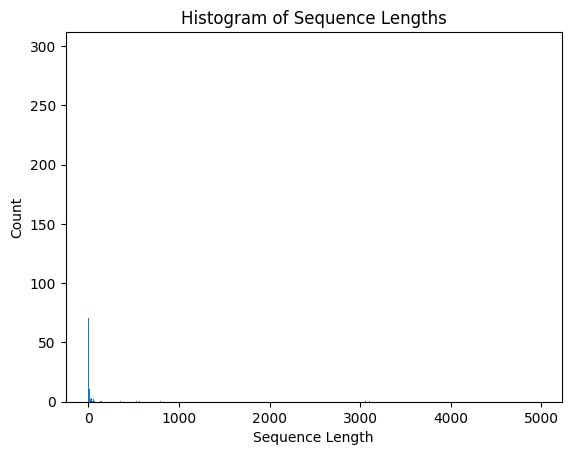

Mean sequence length: 77.29317697228144
Median sequence length: 4.0
Min sequence length: 1
Max sequence length: 4974


In [73]:
lengths = [len(seq) for seq in sequences]
print("Number of sequences:", len(sequences))
print("Sequence lengths:", lengths)

# histogram of sequence lengths
import matplotlib.pyplot as plt
plt.hist(lengths, bins=np.arange(0, max(lengths)+1, 1))
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Histogram of Sequence Lengths")
plt.show()

# statistics of sequence lengths
print("Mean sequence length:", np.mean(lengths))
print("Median sequence length:", np.median(lengths))
print("Min sequence length:", np.min(lengths))
print("Max sequence length:", np.max(lengths))


In [74]:
from scipy.optimize import minimize

def log_likelihood(params, seq):
    mu, alpha, beta, sigma = params
    # Contraintes de positivité
    if mu <= 0 or alpha <= 0 or beta <= 0 or sigma <= 0:
        return 1e10
    
    t, x, y = seq[:, 0], seq[:, 1], seq[:, 2]
    n = len(t)
    ll = 0
    
    # 1. Somme des logs de l'intensité aux points observés
    for i in range(1, n):
        dt = t[i] - t[:i]
        dx = x[i] - x[:i]
        dy = y[i] - y[:i]
        
        # Calcul du noyau spatial (Gaussien) et temporel (Exp)
        spatial = (1 / (2 * np.pi * sigma**2)) * np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
        temporal = beta * np.exp(-beta * dt)
        
        lambda_i = mu + alpha * np.sum(spatial * temporal)
        ll += np.log(lambda_i)
        
    # 2. Terme intégral (approximation sur la durée T de la séquence)
    T = t[-1] - t[0]
    # Intégrale simplifiée : mu*T + alpha * nombre d'événements
    term_int = mu * T + alpha * n 
    
    return -(ll - term_int) # On minimise l'opposé de la log-vraisemblance


In [75]:
import random

# Mélanger les séquences pour ne pas subir de biais temporel (ex: saisonnalité)
random.seed(42)
indices = list(range(len(sequences)))
# random.shuffle(indices)

split_idx = int(0.8 * len(sequences))
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

train_seqs = [sequences[i] for i in train_indices]
test_seqs = [sequences[i] for i in test_indices]

print(f"Orages pour l'entraînement : {len(train_seqs)}")
print(f"Orages pour le test : {len(test_seqs)}")

Orages pour l'entraînement : 750
Orages pour le test : 188


In [78]:
import sys

iteration_count = 0

def total_log_likelihood(params, all_sequences):
    total_ll = 0
    
    # Affichage de l'itération globale de l'optimiseur
    
    
    for i, seq in enumerate(all_sequences):
        sys.stdout.write(f"\rOptimisation - Itération n°{iteration_count} | Séquence {i+1}/{len(all_sequences)}")
        sys.stdout.flush()
        if len(seq) < 2: continue
        total_ll += log_likelihood(params, seq)
        
    return total_ll



In [79]:
# Force mu à être petit et alpha à être significatif
# mu (bruit de fond), alpha (excitation), beta (temps), sigma (espace)
initial_guess = [0.0001, 0.5, 0.2, 5.0] 

# Ajoute des bornes strictes pour éviter que mu n'explose
bounds = [
    (1e-7, 0.01),  # mu doit être très petit (on ne veut pas d'éclairs par magie)
    (0.01, 0.99),  # alpha : un éclair doit générer entre 1% et 99% d'un autre éclair
    (0.01, 1.0),   # beta
    (0.5, 20.0)    # sigma : entre 500m et 20km
]

res = minimize(total_log_likelihood, initial_guess, args=(train_seqs,), 
               method='L-BFGS-B', bounds=bounds)

params_opti = res.x
print("Paramètres optimisés (Train) :", params_opti)

Optimisation - Itération n°0 | Séquence 750/750Paramètres optimisés (Train) : [0.01       0.43177016 0.73870096 0.94268757]


In [80]:
def evaluate_model(params, test_sequences):
    scores = []
    for seq in test_sequences:
        if len(seq) < 2: continue
        # On calcule la LL pour cette séquence avec les paramètres du train
        ll = -log_likelihood(params, seq) 
        scores.append(ll / len(seq)) # LL normalisée par le nombre d'éclairs
    return np.mean(scores)

test_score = evaluate_model(params_opti, test_seqs)
print(f"Log-Likelihood moyenne sur le test : {test_score:.4f}")

Log-Likelihood moyenne sur le test : -4.0539


In [81]:
def evaluate_prediction(params, test_sequences, threshold=0.05):
    results = []
    mu, alpha, beta, sigma = params

    for seq in test_sequences:
        if len(seq) < 5: continue # On a besoin d'un historique
        
        # On simule qu'on est au 3/4 de l'orage
        split = int(len(seq) * 0.7)
        history = seq[:split]
        future = seq[split:]
        
        last_t_obs = history[-1, 0]
        real_next_lightning = future[0, 0] - last_t_obs
        
        # Prédiction du modèle : temps nécessaire pour que lambda retombe à mu + epsilon
        # On résout lambda(t) = mu + threshold
        # Intensité actuelle due au passé :
        current_excitation = alpha * np.sum(beta * np.exp(-beta * (last_t_obs - history[:, 0])))
        
        if current_excitation > 0:
            # Temps théorique pour que l'excitation disparaisse (décroissance exp)
            pred_silence_needed = -np.log(threshold / current_excitation) / beta
        else:
            pred_silence_needed = 0
            
        results.append({
            'pred_wait': pred_silence_needed,
            'real_wait': real_next_lightning,
            'error': pred_silence_needed - real_next_lightning
        })
        
    return pd.DataFrame(results)

df_results = evaluate_prediction(params_opti, test_seqs)
print(df_results.head())
print(f"Erreur moyenne de prédiction : {df_results['error'].mean():.2f} min")

   pred_wait  real_wait     error
0   2.628232  11.650000 -9.021768
1   2.521695  11.300000 -8.778305
2   3.283081   1.150000  2.133081
3   5.080306   0.516667  4.563640
4   3.696647   0.333333  3.363314
Erreur moyenne de prédiction : 0.96 min


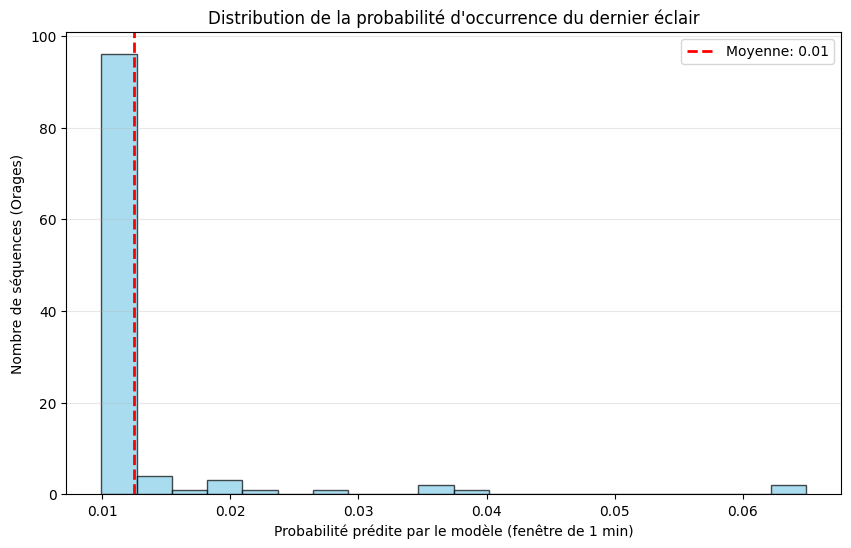

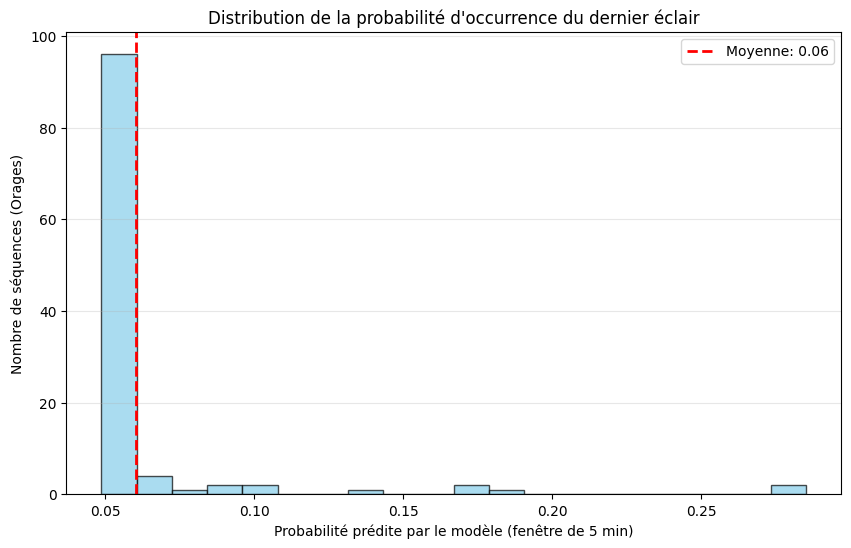

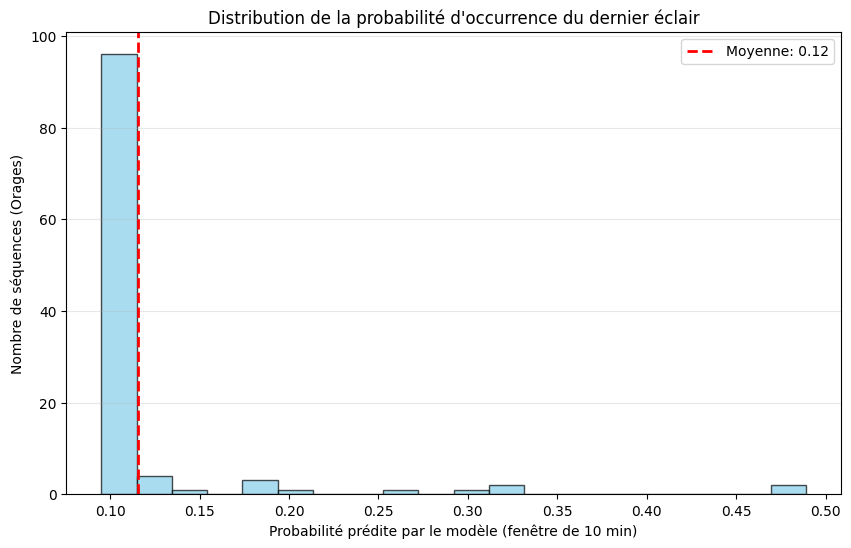

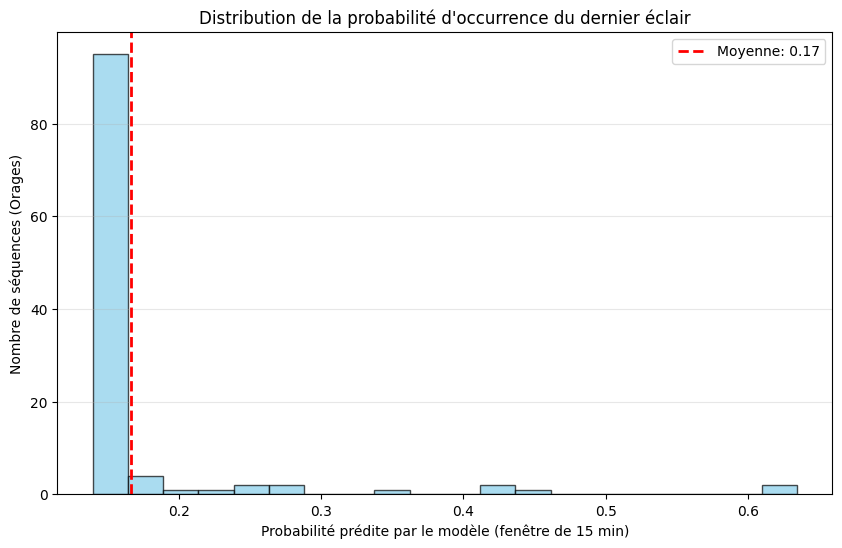

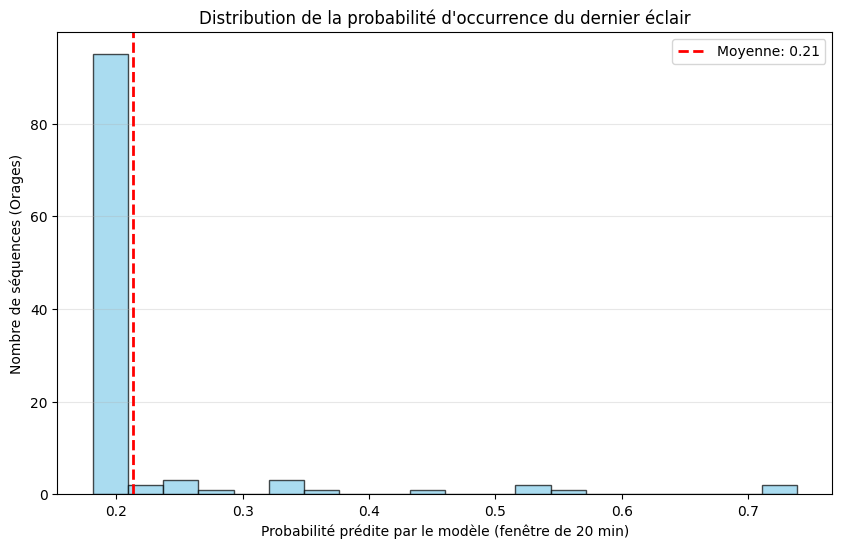

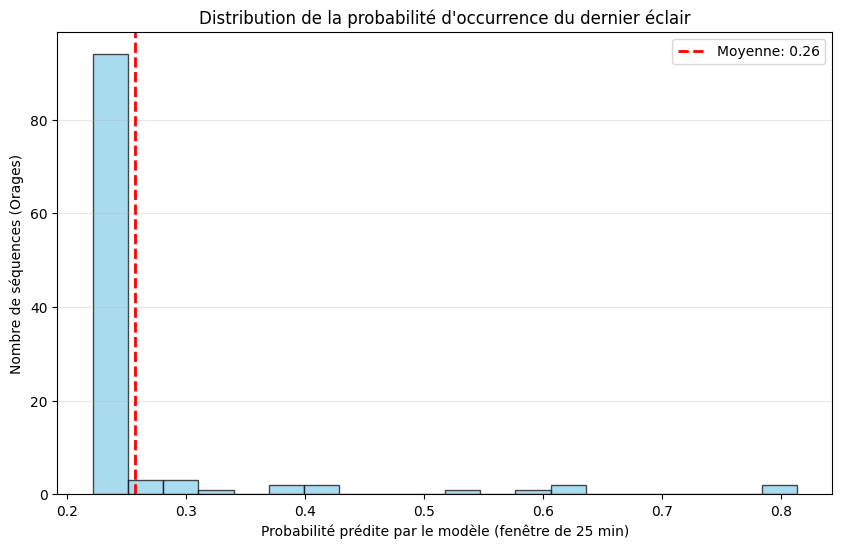

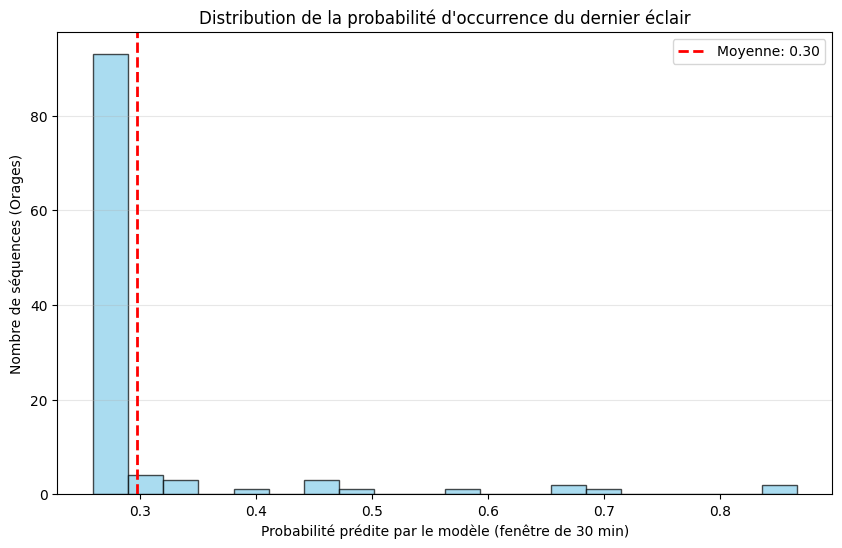

In [86]:
import matplotlib.pyplot as plt

def get_last_lightning_probabilities(params, test_sequences, delta_t):
    # On récupère les 4 paramètres (sigma inclus !)
    mu, alpha, beta, sigma = params
    probs = []

    for seq in test_sequences:
        if len(seq) < 3: continue
        
        history = seq[:-1] 
        last_event = seq[-1]
        
        t_target, x_target, y_target = last_event[0], last_event[1], last_event[2]
        
        # Calcul des distances temporelles ET spatiales
        dt = t_target - history[:, 0]
        dx = x_target - history[:, 1]
        dy = y_target - history[:, 2]
        dist_sq = dx**2 + dy**2 # Distance euclidienne au carré
        
        # Noyau Temporel
        temporal = beta * np.exp(-beta * dt)
        
        # Noyau Spatial (Gaussien)
        spatial = (1 / (2 * np.pi * sigma**2)) * np.exp(-dist_sq / (2 * sigma**2))
        
        # Intensité totale (Somme des excitations + bruit de fond)
        # Chaque éclair passé excite le point cible selon sa distance et son âge
        excitation = np.sum(alpha * temporal * spatial)
        lamb_t = mu + excitation
        
        # Probabilité (fenêtre de delta_t min)
        p_occurrence = 1 - np.exp(-lamb_t * delta_t)
        probs.append(p_occurrence)
        
    return probs

for delta_t in [1, 5, 10, 15, 20, 25, 30]:
    # Récupération des probabilités
    last_lightning_probs = get_last_lightning_probabilities(params_opti, test_seqs, delta_t)

    # --- Affichage de l'Histogramme ---
    plt.figure(figsize=(10, 6))
    plt.hist(last_lightning_probs, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(last_lightning_probs), color='red', linestyle='dashed', linewidth=2, label=f'Moyenne: {np.mean(last_lightning_probs):.2f}')

    plt.title("Distribution de la probabilité d'occurrence du dernier éclair")
    plt.xlabel(f"Probabilité prédite par le modèle (fenêtre de {delta_t} min)")
    plt.ylabel("Nombre de séquences (Orages)")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

All actuals: [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

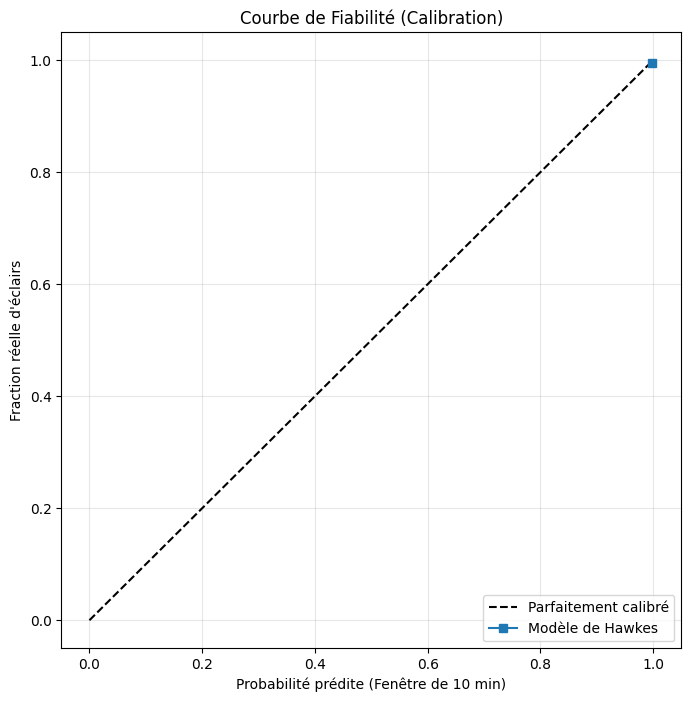

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que 'y_test' sont vos valeurs réelles et 'y_pred' vos prédictions
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Classe 0', 'Classe 1'], 
                yticklabels=['Classe 0', 'Classe 1'])
    plt.xlabel('Prédictions')
    plt.ylabel('Réel')
    plt.title('Matrice de Confusion')
    plt.show()

plot_confusion_matrix(y_test, y_pred)